# Store Split Notebook

## Set Up Environment and Imports

In [346]:
from pathlib import Path

import pandas as pd

## Define Configuration and Constants

In [347]:
CONFIG = {
    "csv_path": Path("eval_results_normalized.csv"),
    "with_store_label": "With_Store",
    "no_store_label": "No_Store",
}

EXPECTED_COLUMNS = {"Condition", "Value"}

## Implement Core Functions

In [348]:
from typing import Iterable, Tuple


def load_results(csv_path: Path) -> pd.DataFrame:
    return pd.read_csv(csv_path)


def clean_condition(df: pd.DataFrame) -> pd.DataFrame:
    cleaned = df.copy()
    if "Condition" in cleaned.columns:
        cleaned["Condition"] = cleaned["Condition"].astype(str).str.strip()
    return cleaned


def validate_schema(df: pd.DataFrame, required_columns: Iterable[str]) -> None:
    missing = sorted(set(required_columns) - set(df.columns))
    if missing:
        raise ValueError(f"Missing required columns: {missing}")


def validate_conditions(df: pd.DataFrame, expected: Iterable[str]) -> None:
    actual = set(df["Condition"].dropna().unique())
    unexpected = sorted(actual - set(expected))
    if unexpected:
        raise ValueError(f"Unexpected Condition values: {unexpected}")


def split_by_condition(
    df: pd.DataFrame,
    with_store_label: str,
    no_store_label: str,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    df_with_store = df[df["Condition"] == with_store_label].reset_index(drop=True)
    df_no_store = df[df["Condition"] == no_store_label].reset_index(drop=True)
    return df_with_store, df_no_store


df_raw = load_results(CONFIG["csv_path"])
validate_schema(df_raw, EXPECTED_COLUMNS)

df_clean = clean_condition(df_raw)
validate_conditions(df_clean, [CONFIG["with_store_label"], CONFIG["no_store_label"]])

df_with_store, df_no_store = split_by_condition(
    df_clean,
    CONFIG["with_store_label"],
    CONFIG["no_store_label"],
)

print("With store shape:", df_with_store.shape)
print("No store shape:", df_no_store.shape)

display(df_with_store.head())
display(df_no_store.head())

With store shape: (4030, 11)
No store shape: (3148, 11)


,Timestamp,Domain,Model,Temp,Eval_Prompt_Ver,Baseline_Prompt_Ver,Runs,Condition,Summary_Metric,Value,Class_Label
0,2026-05-15 00:21:31,loan_absurd,gemma3:1b,0.0,v15,v2,10,With_Store,Average_Accuracy,0.9500,NaN
1,2026-05-15 00:21:31,loan_absurd,gemma3:1b,0.0,v15,v2,10,With_Store,Variance_Raw_Score,0.2778,NaN
2,2026-05-15 00:21:31,loan_absurd,gemma3:1b,0.0,v15,v2,10,With_Store,StdDev_Raw_Score,0.5270,NaN
3,2026-05-15 00:21:31,loan_absurd,gemma3:1b,0.0,v15,v2,10,With_Store,EFR_Extraction_Failure_Rate,0.0300,NaN
4,2026-05-15 00:21:31,loan_absurd,gemma3:1b,0.0,v15,v2,10,With_Store,AFR_Answer_Flip_Rate,0.0200,NaN


,Timestamp,Domain,Model,Temp,Eval_Prompt_Ver,Baseline_Prompt_Ver,Runs,Condition,Summary_Metric,Value,Class_Label
0,2026-05-15 00:21:31,loan_absurd,gemma3:1b,0.0,v15,v2,10,No_Store,Average_Accuracy,0.2100,NaN
1,2026-05-15 00:21:31,loan_absurd,gemma3:1b,0.0,v15,v2,10,No_Store,Variance_Raw_Score,0.7667,NaN
2,2026-05-15 00:21:31,loan_absurd,gemma3:1b,0.0,v15,v2,10,No_Store,StdDev_Raw_Score,0.8756,NaN
3,2026-05-15 00:21:31,loan_absurd,gemma3:1b,0.0,v15,v2,10,No_Store,EFR_Extraction_Failure_Rate,0.0300,NaN
4,2026-05-15 00:21:31,loan_absurd,gemma3:1b,0.0,v15,v2,10,No_Store,AFR_Answer_Flip_Rate,0.0400,NaN


In [349]:
metric_name = "Average_Accuracy"
model_column = "Model"
metric_column = "Summary_Metric"

missing_columns = [col for col in [model_column, metric_column, "Condition", "Value"] if col not in df_clean.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

rename_map = {
    "hoangquan456/qwen3-nothink:4b": "qwen3:4b (no thinking)",
    "hoangquan456/qwen3-nothink:4b": "qwen3:4b (no thinking)",
}

plot_df = df_clean.copy()
plot_df[model_column] = plot_df[model_column].replace(rename_map)

plot_df = plot_df[plot_df[metric_column].astype(str).str.strip().str.lower() == metric_name.lower()]

if plot_df.empty:
    raise ValueError(f"No rows found for {metric_column}={metric_name}")

avg_with_store = (
    plot_df[plot_df["Condition"] == CONFIG["with_store_label"]]
    .groupby(model_column, as_index=False)["Value"]
    .mean()
    .rename(columns={"Value": "with_store"})
)

avg_no_store = (
    plot_df[plot_df["Condition"] == CONFIG["no_store_label"]]
    .groupby(model_column, as_index=False)["Value"]
    .mean()
    .rename(columns={"Value": "no_store"})
)

avg_compare = avg_with_store.merge(avg_no_store, on=model_column, how="outer")

print("Average compare (first rows):")
display(avg_compare.head())

Average compare (first rows):


,Model,with_store,no_store
0,gemma3:1b,0.587778,0.380833
1,gemma4:e2b,0.805500,0.519250
2,llama3.2:1b,0.390556,0.196944
3,ministral-3:3b,0.822727,0.560227
4,qwen3:4b (no thinking),0.828636,0.559091


Condition       scenario_type  no_store  with_store
0                      absurd   0.44975     0.81075
1             absurd_temporal   0.39675     0.73300
2          belief_maintenance   0.60750     0.85525
3                   grounding   0.40425     0.45800


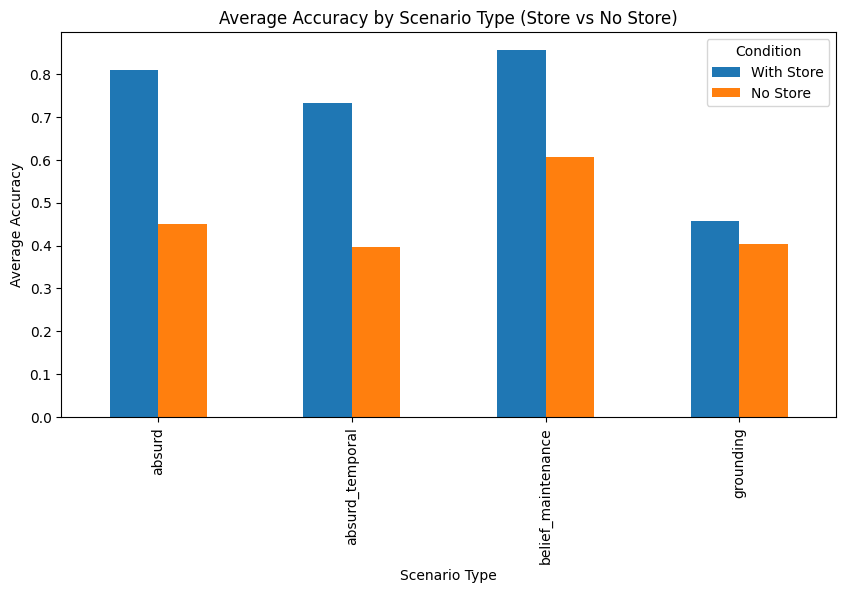

In [350]:
scenario_types = ["grounding", "belief_maintenance", "absurd", "absurd_temporal"]

scenario_df = df_clean.copy()

def extract_scenario_type(domain: str) -> str:
    domain = str(domain).strip()
    for scenario_type in sorted(scenario_types, key=len, reverse=True):
        if domain.endswith(f"_{scenario_type}"):
            return scenario_type
    return "unknown"

scenario_df["scenario_type"] = scenario_df["Domain"].apply(extract_scenario_type)

scenario_df = scenario_df[
    (scenario_df["Summary_Metric"].astype(str).str.strip().str.lower() == "average_accuracy")
    & (scenario_df["scenario_type"].isin(scenario_types))
]

scenario_avg = (
    scenario_df.groupby(["scenario_type", "Condition"], as_index=False)["Value"]
    .mean()
)

scenario_pivot = scenario_avg.pivot(
    index="scenario_type",
    columns="Condition",
    values="Value",
).reset_index()

scenario_pivot = scenario_pivot.rename(
    columns={
        CONFIG["with_store_label"]: "with_store",
        CONFIG["no_store_label"]: "no_store",
    }
)

ax = scenario_pivot.plot(
    x="scenario_type",
    y=["with_store", "no_store"],
    kind="bar",
    figsize=(10, 5),
)
ax.set_title("Average Accuracy by Scenario Type (Store vs No Store)")
ax.set_xlabel("Scenario Type")
ax.set_ylabel("Average Accuracy")
ax.legend(["With Store", "No Store"], title="Condition")

print(scenario_pivot)

In [351]:
per_run_var_df = df_clean.copy()
per_run_var_df[model_column] = per_run_var_df[model_column].replace(rename_map)

per_run_var_df = per_run_var_df[
    per_run_var_df["Summary_Metric"].astype(str).str.strip().str.lower() == "average_accuracy"
]

# Extract scenario type
per_run_var_df["scenario_type"] = per_run_var_df["Domain"].apply(extract_scenario_type)

per_run_var_df = per_run_var_df[per_run_var_df["scenario_type"].isin(scenario_types)]

# Per-model, per-scenario, per-condition: std of Average_Accuracy across individual data points
per_run_var = (
    per_run_var_df.groupby([model_column, "scenario_type", "Condition"], as_index=False)["Value"]
    .std()
    .rename(columns={"Value": "std_accuracy"})
)

per_run_var_pivot = per_run_var.pivot_table(
    index=[model_column, "scenario_type"],
    columns="Condition",
    values="std_accuracy",
).reset_index()

per_run_var_pivot.columns.name = None
per_run_var_pivot = per_run_var_pivot.rename(
    columns={
        CONFIG["with_store_label"]: "with_store",
        CONFIG["no_store_label"]: "no_store",
    }
)

if "with_store" in per_run_var_pivot.columns and "no_store" in per_run_var_pivot.columns:
    per_run_var_pivot["delta_var"] = (
        per_run_var_pivot["with_store"] - per_run_var_pivot["no_store"]
    )

per_run_var_pivot = per_run_var_pivot.sort_values(by=[model_column, "scenario_type"])

print("Per-Model, Per-Scenario Type: Std Dev of Accuracy across Runs (Store vs No Store):")
display(per_run_var_pivot)

Per-Model, Per-Scenario Type: Std Dev of Accuracy across Runs (Store vs No Store):


,Model,scenario_type,no_store,with_store,delta_var
0,gemma3:1b,absurd,0.213738,0.240476,0.026738
1,gemma3:1b,absurd_temporal,0.117587,0.203255,0.085667
2,gemma3:1b,belief_maintenance,0.105754,0.128779,0.023025
3,gemma3:1b,grounding,0.120238,0.111867,-0.008371
4,gemma4:e2b,absurd,0.295172,0.304862,0.009690
5,gemma4:e2b,absurd_temporal,0.284153,0.163527,-0.120626
6,gemma4:e2b,belief_maintenance,0.307292,0.017728,-0.289564
7,gemma4:e2b,grounding,0.268900,0.222032,-0.046868
8,llama3.2:1b,absurd,0.149857,0.197267,0.047410
9,llama3.2:1b,absurd_temporal,0.149571,0.144988,-0.004583


In [352]:
# Check observation counts per model/scenario/condition
obs_counts = (
    per_run_var_df.groupby([model_column, "scenario_type", "Condition"], as_index=False)["Value"]
    .count()
    .rename(columns={"Value": "n_observations"})
)

obs_counts_pivot = obs_counts.pivot_table(
    index=[model_column, "scenario_type"],
    columns="Condition",
    values="n_observations",
).reset_index()

obs_counts_pivot.columns.name = None
obs_counts_pivot = obs_counts_pivot.rename(
    columns={
        CONFIG["with_store_label"]: "with_store_n",
        CONFIG["no_store_label"]: "no_store_n",
    }
)

print("Observation counts per Model, Scenario Type, Condition:")
display(obs_counts_pivot)

Observation counts per Model, Scenario Type, Condition:


,Model,scenario_type,no_store_n,with_store_n
0,gemma3:1b,absurd,8.0,8.0
1,gemma3:1b,absurd_temporal,8.0,8.0
2,gemma3:1b,belief_maintenance,8.0,8.0
3,gemma3:1b,grounding,8.0,8.0
4,gemma4:e2b,absurd,8.0,8.0
5,gemma4:e2b,absurd_temporal,8.0,8.0
6,gemma4:e2b,belief_maintenance,8.0,8.0
7,gemma4:e2b,grounding,8.0,8.0
8,llama3.2:1b,absurd,8.0,8.0
9,llama3.2:1b,absurd_temporal,8.0,8.0


In [353]:
# Per-model × Scenario-type accuracy table (with_store vs no_store)
per_model_scenario_df = df_clean.copy()
per_model_scenario_df[model_column] = per_model_scenario_df[model_column].replace(rename_map)

per_model_scenario_df = per_model_scenario_df[
    per_model_scenario_df["Summary_Metric"].astype(str).str.strip().str.lower() == "average_accuracy"
]

per_model_scenario_df["scenario_type"] = per_model_scenario_df["Domain"].apply(extract_scenario_type)
per_model_scenario_df = per_model_scenario_df[per_model_scenario_df["scenario_type"].isin(scenario_types)]

per_model_avg = (
    per_model_scenario_df.groupby([model_column, "scenario_type", "Condition"], as_index=False)["Value"]
    .mean()
)

# Pivot so each model has columns like grounding_With_Store, grounding_No_Store, etc.
per_model_pivot = per_model_avg.pivot_table(
    index=model_column,
    columns=["scenario_type", "Condition"],
    values="Value",
)

# Flatten multiindex columns
per_model_pivot.columns = [f"{sc}_{cond}" for sc, cond in per_model_pivot.columns]
per_model_pivot = per_model_pivot.reset_index().sort_values(by=model_column)

print("Per-model by scenario-type Average Accuracy (columns: <scenario>_<Condition>):")
display(per_model_pivot)

Per-model by scenario-type Average Accuracy (columns: <scenario>_<Condition>):


,Model,absurd_No_Store,absurd_With_Store,absurd_temporal_No_Store,absurd_temporal_With_Store,belief_maintenance_No_Store,belief_maintenance_With_Store,grounding_No_Store,grounding_With_Store
0,gemma3:1b,0.44625,0.73000,0.38375,0.64625,0.37875,0.74875,0.27000,0.12000
1,gemma4:e2b,0.64875,0.88375,0.50500,0.85625,0.65000,0.99000,0.40750,0.62875
2,llama3.2:1b,0.17000,0.49000,0.14500,0.43750,0.35250,0.56750,0.03125,0.05875
3,ministral-3:3b,0.54250,0.96750,0.49375,0.85375,0.77500,0.99125,0.59625,0.72750
4,qwen3:4b (no thinking),0.44125,0.98250,0.45625,0.87125,0.88125,0.97875,0.71625,0.75500


Comparison: With_Store v15  vs No_Store v1 (per model+domain)


,Model,Domain,with_store_v15,no_store_v1,delta_v15_v1,n_with_store_v15,n_no_store_v1
32,gemma4:e2b,loan_absurd,0.565,0.975,-0.410,2,2
9,gemma3:1b,crime_scene_grounding,0.035,0.345,-0.310,2,2
14,gemma3:1b,loan_grounding,0.115,0.310,-0.195,2,2
81,ministral-3:3b,loan_hard,0.695,0.820,-0.125,2,2
56,llama3.2:1b,loan_absurd_temporal_noise,0.300,0.400,-0.100,1,1
...,...,...,...,...,...,...,...
78,ministral-3:3b,loan_absurd_temporal_noise,1.000,0.400,0.600,1,1
28,gemma4:e2b,crime_scene_absurd_temporal_noise,0.900,0.300,0.600,1,1
101,qwen3:4b (no thinking),loan_absurd_temporal,1.000,0.380,0.620,2,2
100,qwen3:4b (no thinking),loan_absurd,1.000,0.375,0.625,2,2


Model-level mean accuracies (v15 vs v1):


,Model,with_store_v15,no_store_v1
0,gemma3:1b,0.609000,0.389750
1,gemma4:e2b,0.782708,0.496875
2,llama3.2:1b,0.392250,0.214750
3,ministral-3:3b,0.827083,0.551042
4,qwen3:4b (no thinking),0.830417,0.541667


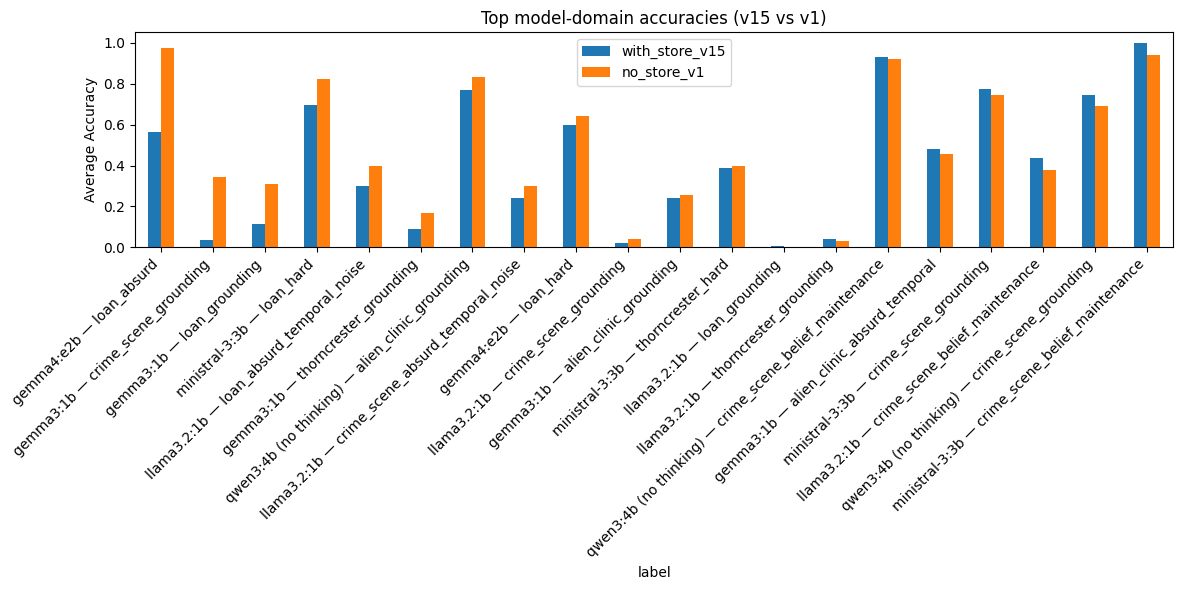

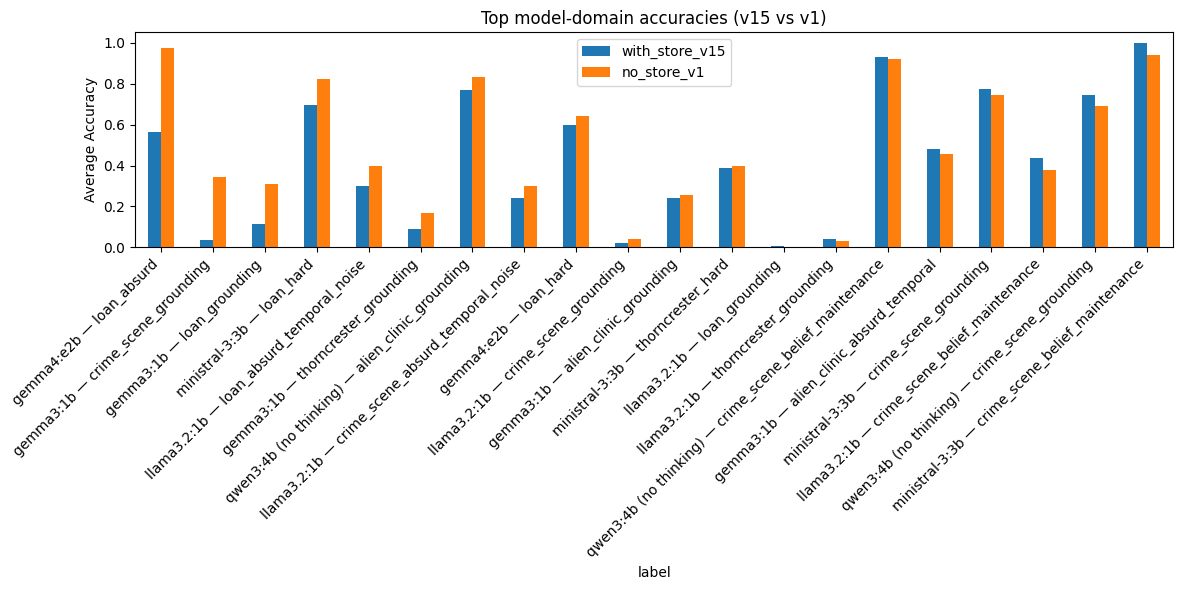

In [354]:
# Compare With_Store v15 vs No_Store v1
comp = df_clean.copy()
comp[model_column] = comp[model_column].replace(rename_map)
comp = comp[comp["Summary_Metric"].astype(str).str.strip().str.lower() == "average_accuracy"]

# ensure scenario_type exists
if "scenario_type" not in comp.columns:
    comp["scenario_type"] = comp["Domain"].apply(extract_scenario_type)

# Build masks safely depending on whether Prompt_Ver exists
if "Prompt_Ver" in comp.columns:
    store_mask = (comp["Condition"] == CONFIG["with_store_label"]) & (comp["Prompt_Ver"] == "v15")
    no_store_mask = (comp["Condition"] == CONFIG["no_store_label"]) & (comp["Prompt_Ver"] == "v1")
else:
    store_mask = comp["Condition"] == CONFIG["with_store_label"]
    no_store_mask = comp["Condition"] == CONFIG["no_store_label"]

store_grp = (
    comp[store_mask].groupby([model_column, "Domain"], as_index=False)["Value"].mean().rename(columns={"Value": "with_store_v15"})
)
no_store_grp = (
    comp[no_store_mask].groupby([model_column, "Domain"], as_index=False)["Value"].mean().rename(columns={"Value": "no_store_v1"})
)

merge_v15 = store_grp.merge(no_store_grp, on=[model_column, "Domain"], how="outer")
merge_v15["delta_v15_v1"] = merge_v15["with_store_v15"] - merge_v15["no_store_v1"]

# counts
counts_store = comp[store_mask].groupby([model_column, "Domain"], as_index=False)["Value"].count().rename(columns={"Value": "n_with_store_v15"})
counts_no = comp[no_store_mask].groupby([model_column, "Domain"], as_index=False)["Value"].count().rename(columns={"Value": "n_no_store_v1"})
merge_v15 = merge_v15.merge(counts_store, on=[model_column, "Domain"], how="left").merge(counts_no, on=[model_column, "Domain"], how="left")

print("Comparison: With_Store v15  vs No_Store v1 (per model+domain)")
display(merge_v15.sort_values(by="delta_v15_v1"))

# Model-level averages for inspection (no duplicate plotting here)
model_level = merge_v15.groupby(model_column, as_index=False)[["with_store_v15", "no_store_v1"]].mean()
# handle missing columns
if "with_store_v15" not in model_level.columns:
    model_level["with_store_v15"] = float('nan')
if "no_store_v1" not in model_level.columns:
    model_level["no_store_v1"] = float('nan')

print("Model-level mean accuracies (v15 vs v1):")
display(model_level)

# Top model-domain rows by negative delta, plot their accuracies side-by-side
top = merge_v15.sort_values(by="delta_v15_v1").head(20).copy()
top['label'] = top[model_column].astype(str) + ' — ' + top['Domain'].astype(str)
fig2, ax2 = plt.subplots(figsize=(12, 6))
# create DataFrame for plotting
top_plot = top[["label", "with_store_v15", "no_store_v1"]].set_index("label")
top_plot.plot.bar(ax=ax2)
ax2.set_title('Top model-domain accuracies (v15 vs v1)')
ax2.set_ylabel('Average Accuracy')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
display(fig2)

Comparison: With_Store v16  vs No_Store v2 (per model+domain)


,Model,Domain,with_store_v16,no_store_v2,delta_v16_v2,n_with_store_v16,n_no_store_v2
32,gemma4:e2b,loan_absurd,0.565,0.975,-0.410,2,2
9,gemma3:1b,crime_scene_grounding,0.035,0.345,-0.310,2,2
14,gemma3:1b,loan_grounding,0.115,0.310,-0.195,2,2
81,ministral-3:3b,loan_hard,0.695,0.820,-0.125,2,2
56,llama3.2:1b,loan_absurd_temporal_noise,0.300,0.400,-0.100,1,1
...,...,...,...,...,...,...,...
78,ministral-3:3b,loan_absurd_temporal_noise,1.000,0.400,0.600,1,1
28,gemma4:e2b,crime_scene_absurd_temporal_noise,0.900,0.300,0.600,1,1
101,qwen3:4b (no thinking),loan_absurd_temporal,1.000,0.380,0.620,2,2
100,qwen3:4b (no thinking),loan_absurd,1.000,0.375,0.625,2,2


Model-level mean accuracies (v16 vs v2):


,Model,with_store_v16,no_store_v2
0,gemma3:1b,0.609000,0.389750
1,gemma4:e2b,0.782708,0.496875
2,llama3.2:1b,0.392250,0.214750
3,ministral-3:3b,0.827083,0.551042
4,qwen3:4b (no thinking),0.830417,0.541667


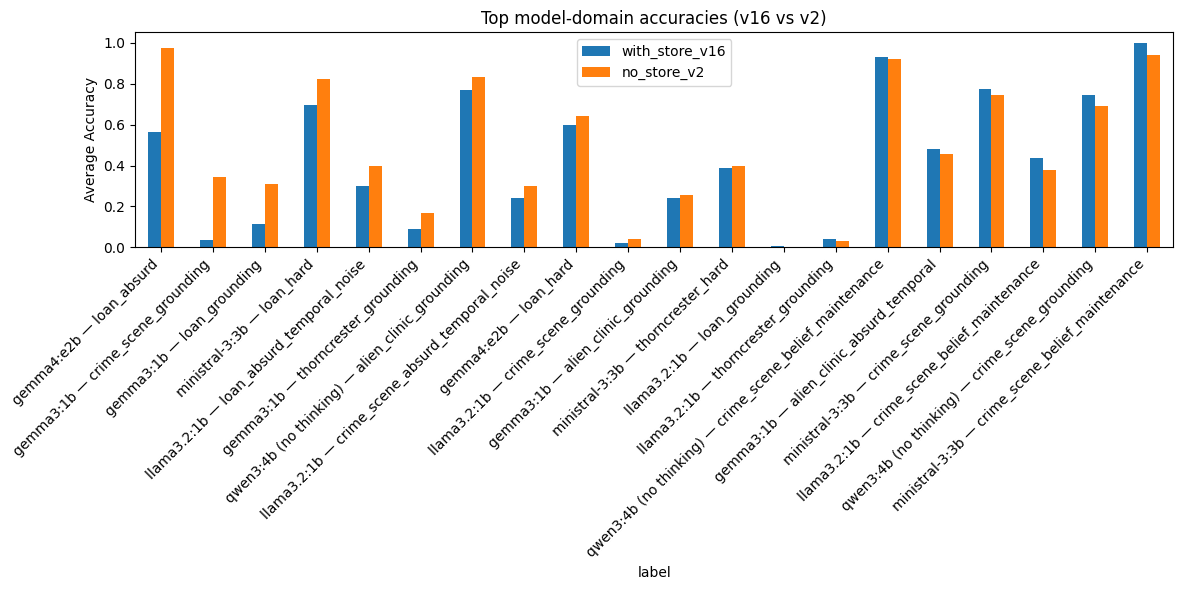

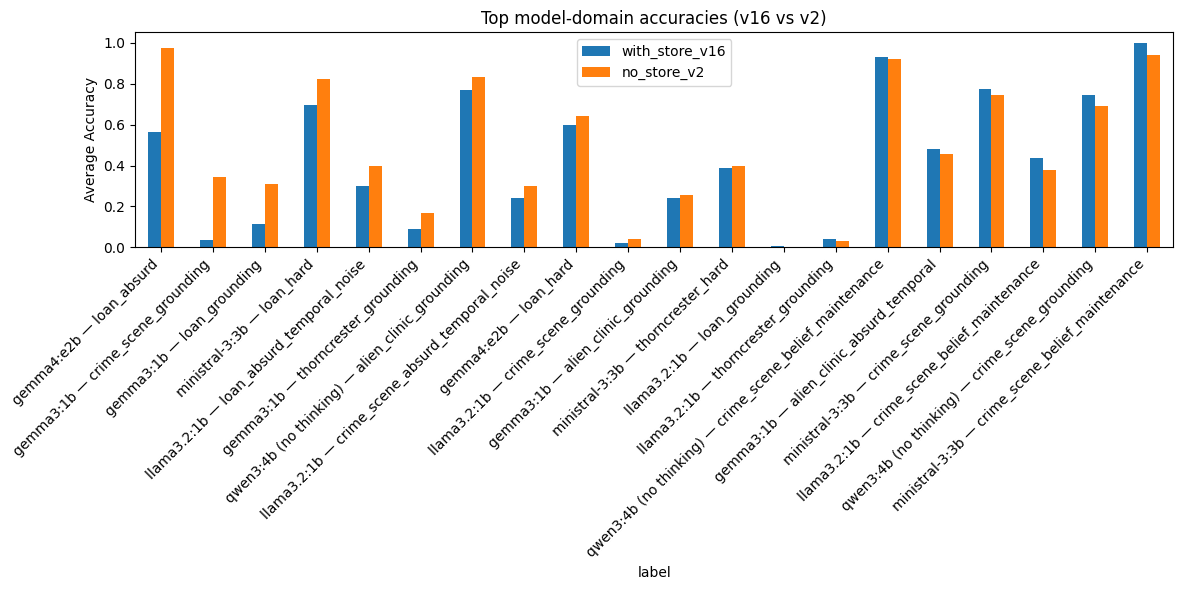

In [355]:
# Compare With_Store v16 vs No_Store v2
comp2 = df_clean.copy()
comp2[model_column] = comp2[model_column].replace(rename_map)
comp2 = comp2[comp2["Summary_Metric"].astype(str).str.strip().str.lower() == "average_accuracy"]

if "scenario_type" not in comp2.columns:
    comp2["scenario_type"] = comp2["Domain"].apply(extract_scenario_type)

if "Prompt_Ver" in comp2.columns:
    store_mask = (comp2["Condition"] == CONFIG["with_store_label"]) & (comp2["Prompt_Ver"] == "v16")
    no_store_mask = (comp2["Condition"] == CONFIG["no_store_label"]) & (comp2["Prompt_Ver"] == "v2")
else:
    store_mask = comp2["Condition"] == CONFIG["with_store_label"]
    no_store_mask = comp2["Condition"] == CONFIG["no_store_label"]

store_grp = (
    comp2[store_mask].groupby([model_column, "Domain"], as_index=False)["Value"].mean().rename(columns={"Value": "with_store_v16"})
)
no_store_grp = (
    comp2[no_store_mask].groupby([model_column, "Domain"], as_index=False)["Value"].mean().rename(columns={"Value": "no_store_v2"})
)

merge_v16 = store_grp.merge(no_store_grp, on=[model_column, "Domain"], how="outer")
merge_v16["delta_v16_v2"] = merge_v16["with_store_v16"] - merge_v16["no_store_v2"]

# counts
counts_store = comp2[store_mask].groupby([model_column, "Domain"], as_index=False)["Value"].count().rename(columns={"Value": "n_with_store_v16"})
counts_no = comp2[no_store_mask].groupby([model_column, "Domain"], as_index=False)["Value"].count().rename(columns={"Value": "n_no_store_v2"})
merge_v16 = merge_v16.merge(counts_store, on=[model_column, "Domain"], how="left").merge(counts_no, on=[model_column, "Domain"], how="left")

print("Comparison: With_Store v16  vs No_Store v2 (per model+domain)")
display(merge_v16.sort_values(by="delta_v16_v2"))

# Model-level averages for inspection (no duplicate plotting here)
model_level = merge_v16.groupby(model_column, as_index=False)[["with_store_v16", "no_store_v2"]].mean()
if "with_store_v16" not in model_level.columns:
    model_level["with_store_v16"] = float('nan')
if "no_store_v2" not in model_level.columns:
    model_level["no_store_v2"] = float('nan')

print("Model-level mean accuracies (v16 vs v2):")
display(model_level)

# Top model-domain rows by negative delta, plot their accuracies side-by-side
top = merge_v16.sort_values(by="delta_v16_v2").head(20).copy()
top['label'] = top[model_column].astype(str) + ' — ' + top['Domain'].astype(str)
fig2, ax2 = plt.subplots(figsize=(12, 6))
top_plot = top[["label", "with_store_v16", "no_store_v2"]].set_index("label")
top_plot.plot.bar(ax=ax2)
ax2.set_title('Top model-domain accuracies (v16 vs v2)')
ax2.set_ylabel('Average Accuracy')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
display(fig2)

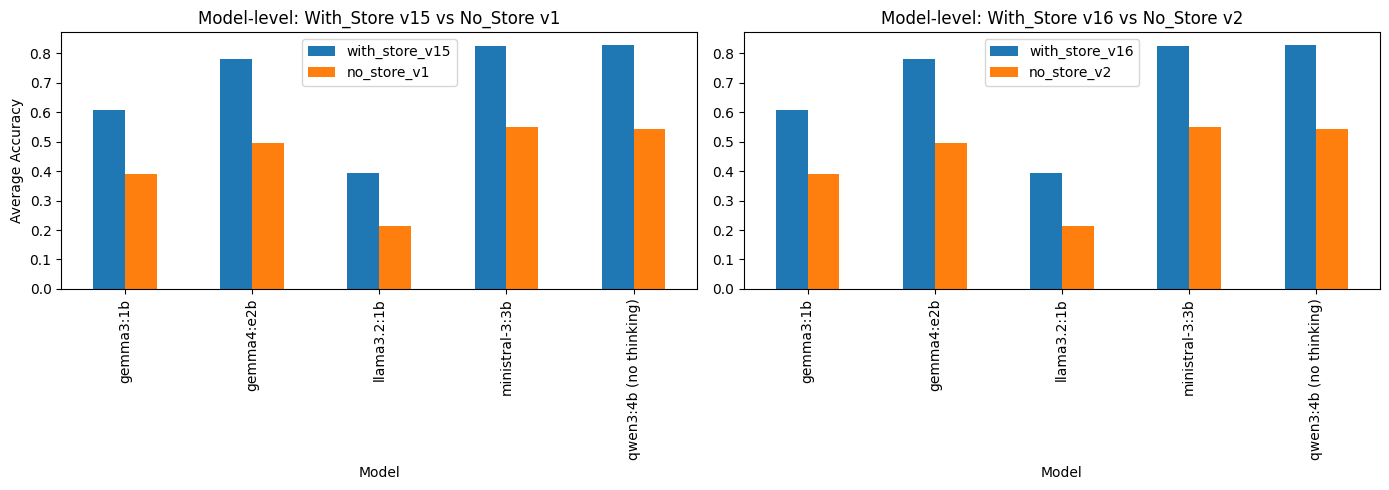

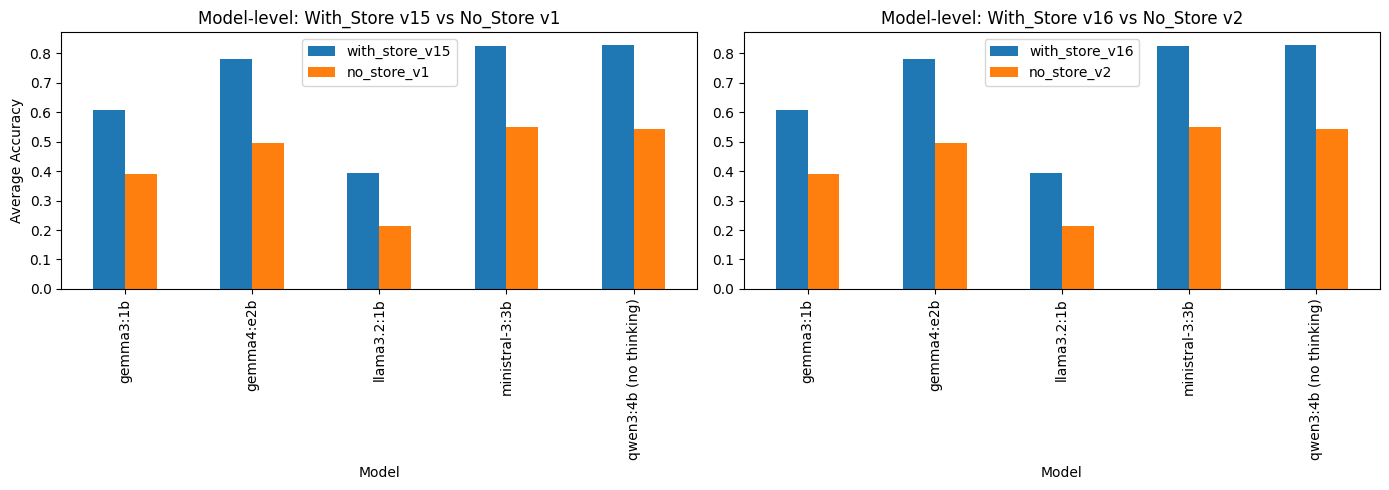

In [356]:
# Consolidated Model-level Comparison Plots for v15 and v16
import matplotlib.pyplot as plt

# prepare model-level data if available
m15 = None
m16 = None
if 'merge_v15' in globals():
    try:
        m15 = merge_v15.groupby(model_column, as_index=False)[['with_store_v15', 'no_store_v1']].mean()
    except Exception:
        m15 = None
if 'merge_v16' in globals():
    try:
        m16 = merge_v16.groupby(model_column, as_index=False)[['with_store_v16', 'no_store_v2']].mean()
    except Exception:
        m16 = None

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if m15 is not None and not m15.empty:
    m15.plot.bar(x=model_column, y=['with_store_v15', 'no_store_v1'], ax=axes[0])
    axes[0].set_title('Model-level: With_Store v15 vs No_Store v1')
    axes[0].set_ylabel('Average Accuracy')
else:
    axes[0].text(0.5, 0.5, 'v15 data not available', ha='center')

if m16 is not None and not m16.empty:
    m16.plot.bar(x=model_column, y=['with_store_v16', 'no_store_v2'], ax=axes[1])
    axes[1].set_title('Model-level: With_Store v16 vs No_Store v2')
else:
    axes[1].text(0.5, 0.5, 'v16 data not available', ha='center')

plt.tight_layout()
display(fig)

Hard accuracy comparison (with_store vs no_store):


Condition,Model,no_store,with_store,delta_store_minus_no_store
0,gemma4:e2b,0.33500,0.4875,0.15250
1,ministral-3:3b,0.44875,0.5475,0.09875
2,qwen3:4b (no thinking),0.40500,0.5450,0.14000


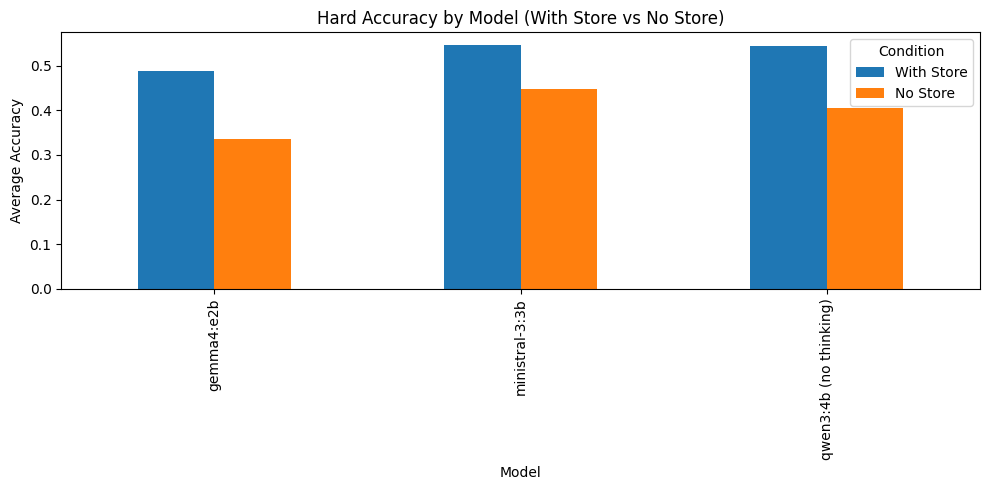

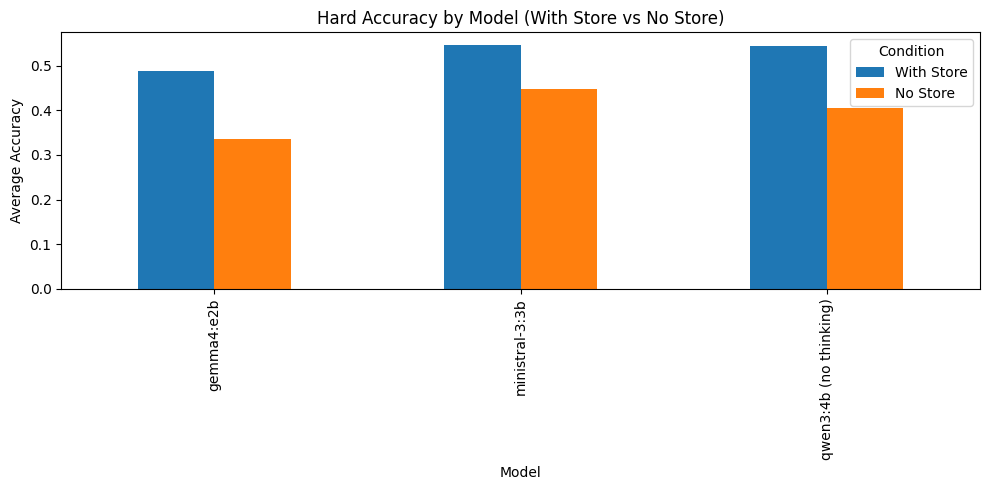

In [357]:
# Hard Accuracy Comparison: With_Store vs No_Store for key models
import matplotlib.pyplot as plt

hard_models = ["ministral-3:3b", "gemma4:e2b", "qwen3:4b (no thinking)"]

hard_df = df_clean.copy()
hard_df[model_column] = hard_df[model_column].replace(rename_map)

required_hard_columns = [model_column, "Domain", "Condition", "Summary_Metric", "Value"]
missing_hard_columns = [col for col in required_hard_columns if col not in hard_df.columns]
if missing_hard_columns:
    raise ValueError(f"Missing required columns for hard comparison: {missing_hard_columns}")

hard_df = hard_df[
    hard_df["Summary_Metric"].astype(str).str.strip().str.lower() == "average_accuracy"
].copy()

hard_df = hard_df[hard_df["Domain"].astype(str).str.endswith("_hard")]
hard_df = hard_df[hard_df[model_column].isin(hard_models)]

if hard_df.empty:
    raise ValueError("No hard-accuracy rows found for the requested models")

hard_summary = (
    hard_df.groupby([model_column, "Condition"], as_index=False)["Value"]
    .mean()
    .rename(columns={"Value": "average_accuracy"})
)

hard_pivot = hard_summary.pivot(
    index=model_column,
    columns="Condition",
    values="average_accuracy",
).rename(columns={
    CONFIG["with_store_label"]: "with_store",
    CONFIG["no_store_label"]: "no_store",
})

for column in ["with_store", "no_store"]:
    if column not in hard_pivot.columns:
        hard_pivot[column] = float("nan")

hard_pivot = hard_pivot.reset_index()
hard_pivot["delta_store_minus_no_store"] = hard_pivot["with_store"] - hard_pivot["no_store"]
hard_pivot = hard_pivot.sort_values(by=model_column)

print("Hard accuracy comparison (with_store vs no_store):")
display(hard_pivot)

ax = hard_pivot.plot(
    x=model_column,
    y=["with_store", "no_store"],
    kind="bar",
    figsize=(10, 5),
)
ax.set_title("Hard Accuracy by Model (With Store vs No Store)")
ax.set_xlabel("Model")
ax.set_ylabel("Average Accuracy")
ax.legend(["With Store", "No Store"], title="Condition")
plt.tight_layout()
display(ax.figure)


In [358]:
# Check which Domains and Models were NOT run with specific eval/baseline prompt versions
import pandas as pd

# Always reload from CSV so this cell reflects latest normalization changes
df_cov = pd.read_csv(CONFIG["csv_path"]).copy()

required_cov_cols = ["Domain", "Model", "Eval_Prompt_Ver", "Baseline_Prompt_Ver"]
missing_cov_cols = [c for c in required_cov_cols if c not in df_cov.columns]
if missing_cov_cols:
    raise ValueError(f"Coverage check is missing columns: {missing_cov_cols}")

# normalize prompt/version strings for safe comparison
df_cov["Eval_Prompt_Ver_norm"] = df_cov["Eval_Prompt_Ver"].astype(str).str.strip().str.lower()
df_cov["Baseline_Prompt_Ver_norm"] = df_cov["Baseline_Prompt_Ver"].astype(str).str.strip().str.lower()

domains = sorted(df_cov["Domain"].dropna().unique())
models = sorted(df_cov["Model"].dropna().unique())

check_eval_versions = ["v16", "v15"]
check_baseline_versions = ["v1", "v2"]

missing_eval = {}
for ev in check_eval_versions:
    present = set(df_cov.loc[df_cov["Eval_Prompt_Ver_norm"] == ev, "Domain"].dropna().unique())
    missing_eval[ev] = [d for d in domains if d not in present]

missing_baseline = {}
for bv in check_baseline_versions:
    present = set(df_cov.loc[df_cov["Baseline_Prompt_Ver_norm"] == bv, "Domain"].dropna().unique())
    missing_baseline[bv] = [d for d in domains if d not in present]

print("Domains missing Eval prompt versions:")
for ev, miss in missing_eval.items():
    print(f" - {ev}: {len(miss)} missing")
    if miss:
        display(pd.DataFrame({"Domain": miss}))

print("\nDomains missing Baseline prompt versions:")
for bv, miss in missing_baseline.items():
    print(f" - {bv}: {len(miss)} missing")
    if miss:
        display(pd.DataFrame({"Domain": miss}))

# Per-domain summary of observed prompt versions
summary_rows = []
for d in domains:
    evs = sorted(df_cov.loc[df_cov["Domain"] == d, "Eval_Prompt_Ver_norm"].dropna().unique())
    bvs = sorted(df_cov.loc[df_cov["Domain"] == d, "Baseline_Prompt_Ver_norm"].dropna().unique())
    summary_rows.append({
        "Domain": d,
        "eval_prompt_versions": ", ".join(evs),
        "baseline_prompt_versions": ", ".join(bvs),
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df.sort_values("Domain").reset_index(drop=True))

# Per-model missing domain coverage per version
model_missing = []
for m in models:
    mdf = df_cov[df_cov["Model"] == m]
    for ev in check_eval_versions:
        present = set(mdf.loc[mdf["Eval_Prompt_Ver_norm"] == ev, "Domain"].dropna().unique())
        missing = [d for d in domains if d not in present]
        if missing:
            model_missing.append({
                "Model": m,
                "type": "eval",
                "version": ev,
                "missing_domains": ", ".join(missing),
            })
    for bv in check_baseline_versions:
        present = set(mdf.loc[mdf["Baseline_Prompt_Ver_norm"] == bv, "Domain"].dropna().unique())
        missing = [d for d in domains if d not in present]
        if missing:
            model_missing.append({
                "Model": m,
                "type": "baseline",
                "version": bv,
                "missing_domains": ", ".join(missing),
            })

model_missing_df = pd.DataFrame(model_missing)
if not model_missing_df.empty:
    print("\nModels with missing domain coverage by version:")
    display(model_missing_df.sort_values(["Model", "type", "version"]).reset_index(drop=True))
else:
    print("\nNo model-level missing coverage detected for the checked versions.")

Domains missing Eval prompt versions:
 - v16: 4 missing


,Domain
0,alien_clinic_absurd_temporal_noise
1,crime_scene_absurd_temporal_noise
2,loan_absurd_temporal_noise
3,thorncrester_absurd_temporal_noise


 - v15: 0 missing

Domains missing Baseline prompt versions:
 - v1: 4 missing


,Domain
0,alien_clinic_absurd_temporal_noise
1,crime_scene_absurd_temporal_noise
2,loan_absurd_temporal_noise
3,thorncrester_absurd_temporal_noise


 - v2: 0 missing


,Domain,eval_prompt_versions,baseline_prompt_versions
0,alien_clinic_absurd,"v15, v16","v1, v2"
1,alien_clinic_absurd_temporal,"v15, v16","v1, v2"
2,alien_clinic_absurd_temporal_noise,v15,v2
3,alien_clinic_belief_maintenance,"v15, v16","v1, v2"
4,alien_clinic_grounding,"v15, v16","v1, v2"
5,alien_clinic_hard,"v15, v16","v1, v2"
6,crime_scene_absurd,"v15, v16","v1, v2"
7,crime_scene_absurd_temporal,"v15, v16","v1, v2"
8,crime_scene_absurd_temporal_noise,v15,v2
9,crime_scene_belief_maintenance,"v15, v16","v1, v2"



Models with missing domain coverage by version:


,Model,type,version,missing_domains
0,gemma3:1b,baseline,v1,"alien_clinic_absurd_temporal_noise, alien_clin..."
1,gemma3:1b,baseline,v2,"alien_clinic_hard, crime_scene_hard, loan_hard..."
2,gemma3:1b,eval,v15,"alien_clinic_hard, crime_scene_hard, loan_hard..."
3,gemma3:1b,eval,v16,"alien_clinic_absurd_temporal_noise, alien_clin..."
4,gemma4:e2b,baseline,v1,"alien_clinic_absurd_temporal_noise, crime_scen..."
5,gemma4:e2b,baseline,v2,"alien_clinic_hard, crime_scene_hard, loan_hard..."
6,gemma4:e2b,eval,v15,"alien_clinic_hard, crime_scene_hard, loan_hard..."
7,gemma4:e2b,eval,v16,"alien_clinic_absurd_temporal_noise, crime_scen..."
8,hoangquan456/qwen3-nothink:4b,baseline,v1,"alien_clinic_absurd_temporal_noise, crime_scen..."
9,hoangquan456/qwen3-nothink:4b,eval,v16,"alien_clinic_absurd_temporal_noise, crime_scen..."


In [359]:
metric_labels = {
    "AFR_Answer_Flip_Rate": "AFR",
    "Summary_Metric_Brier_Score": "Brier",
    "Summary_Metric_ECE": "ECE",
    "Summary_Metric_MacroCE": "MacroECE",
}

metrics_df = df_clean.copy()
metrics_df[model_column] = metrics_df[model_column].replace(rename_map)

metrics_df = metrics_df[metrics_df["Summary_Metric"].isin(metric_labels.keys())]

metrics_summary = (
    metrics_df.groupby([model_column, "Condition", "Summary_Metric"], as_index=False)["Value"]
    .mean()
)

metrics_table = metrics_summary.pivot(
    index=[model_column, "Condition"],
    columns="Summary_Metric",
    values="Value",
).rename(columns=metric_labels)

metrics_table = metrics_table.reset_index().sort_values(by=[model_column, "Condition"])


def format_sigfigs(value: float, sig: int = 3) -> str:
    if pd.isna(value):
        return value
    if value == 0:
        return "0"
    return f"{value:.{sig}g}"


metrics_table_display = metrics_table.copy()
for col in metric_labels.values():
    if col in metrics_table_display.columns:
        metrics_table_display[col] = metrics_table_display[col].apply(
            lambda v: format_sigfigs(v * 100, 3)
        )

display(metrics_table_display)

Summary_Metric,Model,Condition,AFR,Brier,ECE,MacroECE
0,gemma3:1b,No_Store,10.6,53.3,55.2,48.7
1,gemma3:1b,With_Store,3.89,33.8,34.8,44.3
2,gemma4:e2b,No_Store,6.68,32.4,32.6,45.2
3,gemma4:e2b,With_Store,1.56,17.5,17.7,32
4,llama3.2:1b,No_Store,6.78,35.4,40.4,52.4
5,llama3.2:1b,With_Store,6.19,34.6,35.2,45.7
6,ministral-3:3b,No_Store,8.18,29.7,29.4,45
7,ministral-3:3b,With_Store,2.2,16.1,16.6,34.3
8,qwen3:4b (no thinking),No_Store,7.77,39.8,39.9,46.8
9,qwen3:4b (no thinking),With_Store,1.4,16.7,16.7,33.9


In [360]:
delta_metric = "Average_Accuracy"

delta_df = df_clean.copy()
delta_df[model_column] = delta_df[model_column].replace(rename_map)

delta_df = delta_df[
    delta_df["Summary_Metric"].astype(str).str.strip().str.lower() == delta_metric.lower()
]

delta_summary = (
    delta_df.groupby([model_column, "Domain", "Condition"], as_index=False)["Value"]
    .mean()
)

delta_pivot = delta_summary.pivot(
    index=[model_column, "Domain"],
    columns="Condition",
    values="Value",
).rename(columns={
    CONFIG["with_store_label"]: "with_store",
    CONFIG["no_store_label"]: "no_store",
})

if "with_store" in delta_pivot.columns and "no_store" in delta_pivot.columns:
    delta_pivot["delta_store_minus_no_store"] = (
        delta_pivot["with_store"] - delta_pivot["no_store"]
    )

worst_negative = (
    delta_pivot.reset_index()
    .sort_values(by="delta_store_minus_no_store", ascending=True)
    .head(10)
)

display(worst_negative)

Condition,Model,Domain,no_store,with_store,delta_store_minus_no_store
32,gemma4:e2b,loan_absurd,0.975,0.565,-0.410
9,gemma3:1b,crime_scene_grounding,0.345,0.035,-0.310
14,gemma3:1b,loan_grounding,0.310,0.115,-0.195
81,ministral-3:3b,loan_hard,0.820,0.695,-0.125
56,llama3.2:1b,loan_absurd_temporal_noise,0.400,0.300,-0.100
19,gemma3:1b,thorncrester_grounding,0.170,0.090,-0.080
92,qwen3:4b (no thinking),alien_clinic_grounding,0.830,0.770,-0.060
51,llama3.2:1b,crime_scene_absurd_temporal_noise,0.300,0.240,-0.060
37,gemma4:e2b,loan_hard,0.640,0.600,-0.040
53,llama3.2:1b,crime_scene_grounding,0.040,0.020,-0.020


In [361]:
diagnostic_metric = "Average_Accuracy"

diagnostic_df = df_clean.copy()
diagnostic_df[model_column] = diagnostic_df[model_column].replace(rename_map)

diagnostic_df = diagnostic_df[
    diagnostic_df["Summary_Metric"].astype(str).str.strip().str.lower() == diagnostic_metric.lower()
]

diagnostic_summary = (
    diagnostic_df.groupby([model_column, "Domain", "Condition"], as_index=False)["Value"]
    .mean()
)

diagnostic_pivot = diagnostic_summary.pivot(
    index=[model_column, "Domain"],
    columns="Condition",
    values="Value",
).rename(columns={
    CONFIG["with_store_label"]: "with_store",
    CONFIG["no_store_label"]: "no_store",
})

diagnostic_pivot["delta_store_minus_no_store"] = (
    diagnostic_pivot["with_store"] - diagnostic_pivot["no_store"]
)

model_delta_summary = (
    diagnostic_pivot.reset_index()
    .groupby(model_column, as_index=False)["delta_store_minus_no_store"]
    .agg(
        mean_delta="mean",
        median_delta="median",
        negative_count=lambda s: (s < 0).sum(),
        positive_count=lambda s: (s > 0).sum(),
    )
    .sort_values(by="mean_delta")
)

display(model_delta_summary)

,Model,mean_delta,median_delta,negative_count,positive_count
2,llama3.2:1b,0.177500,0.1525,3,17
0,gemma3:1b,0.219250,0.2500,4,16
3,ministral-3:3b,0.276042,0.2650,2,22
1,gemma4:e2b,0.285833,0.3125,2,22
4,qwen3:4b (no thinking),0.288750,0.2700,1,23


## Add Basic Tests and Assertions

In [362]:
expected_conditions = {CONFIG["with_store_label"], CONFIG["no_store_label"]}
actual_conditions = set(df_clean["Condition"].dropna().unique())

assert actual_conditions <= expected_conditions
assert len(df_with_store) + len(df_no_store) <= len(df_clean)
assert (df_with_store["Condition"] == CONFIG["with_store_label"]).all()
assert (df_no_store["Condition"] == CONFIG["no_store_label"]).all()

print("Assertions passed.")

Assertions passed.
